# **Project Setup & Imports**

In [ ]:
# 1. Import Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# 2. Import NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import spacy

# 3. Download NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# 4. Import ML/DL Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
import zipfile
import os
import glob

# Directory where all zip files exist
zip_dir = "/content"

# Directory where you want to extract everything
extract_dir = "/content/spooky_data"

# Create the folder if not exists
os.makedirs(extract_dir, exist_ok=True)

# Get all .zip files in /content
zip_files = glob.glob(os.path.join(zip_dir, "*.zip"))

# Unzip each file
for z in zip_files:
    print("Unzipping:", z)
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

print("✔ Done! All files extracted.")

# Folder containing train.zip, test.zip, sample_submission.zip
zip_dir = "/content/spooky_data"

# Find all zip files inside spooky_data
zip_files = glob.glob(os.path.join(zip_dir, "*.zip"))

# Unzip each one
for z in zip_files:
    print("Unzipping:", z)
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(zip_dir)

print("✔ All inner ZIP files extracted successfully!")


✔ Done! All files extracted.
✔ All inner ZIP files extracted successfully!


# **`Data Loading`**

In [ ]:
# 1.1 Load Dataset
df = pd.read_csv('/content/spooky_data/train.csv')

# 1.2 Initial Data Inspection
print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())

# 1.3 Check Data Types and Missing Values
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (19579, 3)

Dataset Columns: ['id', 'text', 'author']

First 5 Rows:


,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL



Data Types:
id        object
text      object
author    object
dtype: object

Missing Values:
id        0
text      0
author    0
dtype: int64


# **Exploratory Data Analysis (EDA)**

Author counts:
author
EAP    7900
MWS    6044
HPL    5635
Name: count, dtype: int64


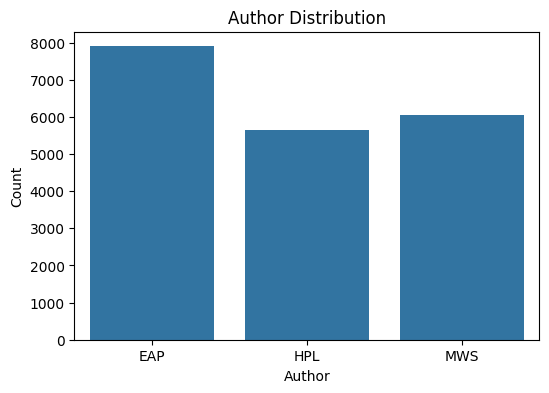

In [ ]:
# ============================
#  Author Distribution
# ============================

# Show the number of samples for each author
print("Author counts:")
print(df['author'].value_counts())

# Visualize class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='author')
plt.title("Author Distribution")
plt.xlabel("Author")
plt.ylabel("Count")
plt.show()


Average text length per author:
author
EAP    142.225949
HPL    155.843478
MWS    151.659828
Name: text_length, dtype: float64


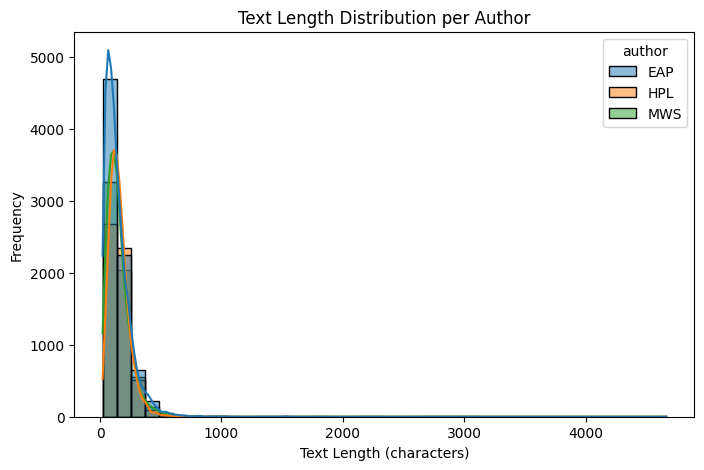

In [ ]:
# ============================
#  Text Length Analysis
# ============================

# Add a column containing the number of characters in each text
df['text_length'] = df['text'].apply(len)

# Show the average text length for each author
print("\nAverage text length per author:")
print(df.groupby('author')['text_length'].mean())

# Visualize text length distribution for each author
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='author', kde=True, bins=40)
plt.title("Text Length Distribution per Author")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.show()



Average word count per author:
author
EAP    25.442405
HPL    27.799645
MWS    27.417273
Name: word_count, dtype: float64


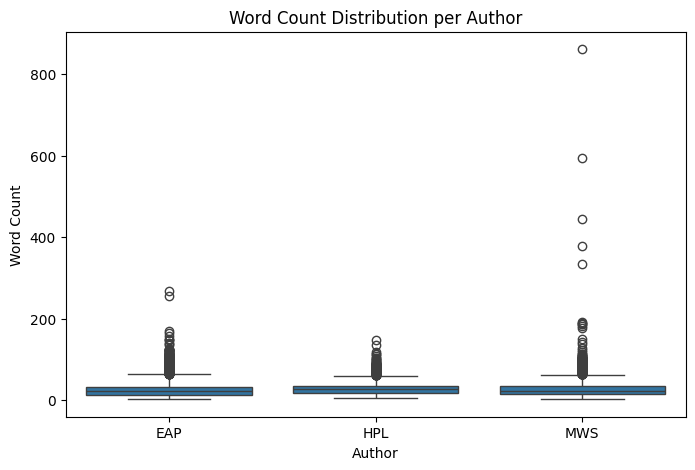

In [ ]:
# ============================
#  Word Count Analysis
# ============================

# Add a column containing the number of words in each text
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Show the average number of words per author
print("\nAverage word count per author:")
print(df.groupby('author')['word_count'].mean())

# Visualize word count distribution using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='author', y='word_count')
plt.title("Word Count Distribution per Author")
plt.xlabel("Author")
plt.ylabel("Word Count")
plt.show()


# **Text Preprocessing**

In [ ]:
# 3.1 Define Preprocessing Functions
def clean_text(text):
    """
    Comprehensive text cleaning function
    """
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

def tokenize_text(text):
    """Tokenize text into words"""
    return word_tokenize(text)

def remove_stopwords(tokens):
    """Remove stopwords from token list"""
    stop_words = set(stopwords.words('english'))
    return [word for word in tokens if word not in stop_words]

def lemmatize_text(tokens):
    """Lemmatize tokens"""
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]

# 3.2 Complete Preprocessing Pipeline
def preprocess_pipeline(text):
    """Complete preprocessing pipeline"""
    # Step 1: Clean text
    text = clean_text(text)

    # Step 2: Tokenize
    tokens = tokenize_text(text)

    # Step 3: Remove stopwords
    tokens = remove_stopwords(tokens)

    # Step 4: Lemmatize
    tokens = lemmatize_text(tokens)

    # Step 5: Rejoin tokens
    return ' '.join(tokens)

# 3.3 Apply Preprocessing
print("Before preprocessing example:", df['text'].iloc[0])
df['cleaned_text'] = df['text'].apply(preprocess_pipeline)
print("After preprocessing example:", df['cleaned_text'].iloc[0])

# 3.4 Show Before-After Comparison
comparison_df = pd.DataFrame({
    'Original': df['text'].head(3),
    'Cleaned': df['cleaned_text'].head(3)
})
display(comparison_df)

Before preprocessing example: This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might make its circuit, and return to the point whence I set out, without being aware of the fact; so perfectly uniform seemed the wall.
After preprocessing example: process however afforded mean ascertaining dimension dungeon might make circuit return point whence set without aware fact perfectly uniform seemed wall


,Original,Cleaned
0,"This process, however, afforded me no means of...",process however afforded mean ascertaining dim...
1,It never once occurred to me that the fumbling...,never occurred fumbling might mere mistake
2,"In his left hand was a gold snuff box, from wh...",left hand gold snuff box capered hill cutting ...


# **Feature Engineering**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,3),
                             min_df=2,
                             max_df=0.9,
                             sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (19579, 32570)


In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(len)
df['avg_word_len'] = df['text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split())
)
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

df['avg_sentence_len'] = df['word_count'] / df['sentence_count']
import string

def punctuation_ratio(text):
    punct = sum(1 for c in text if c in string.punctuation)
    return punct / len(text)

df['punct_ratio'] = df['text'].apply(punctuation_ratio)
def vocab_richness(text):
    words = text.lower().split()
    return len(set(words)) / len(words)

df['vocab_richness'] = df['text'].apply(vocab_richness)
style_features = df[
    [
        'word_count',
        'char_count',
        'avg_word_len',
        'sentence_count',
        'avg_sentence_len',
        'punct_ratio',
        'vocab_richness'
    ]
]

In [ ]:
from scipy.sparse import hstack

X_final = hstack([X_tfidf, style_features.values])

print("Final feature matrix shape:", X_final.shape)

Final feature matrix shape: (19579, 32577)


# **Model Building**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode author labels
le = LabelEncoder()
y = le.fit_transform(df['author'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Multinomial Naive Bayes**

Naive Bayes Accuracy: 0.8340143003064351
Naive Bayes F1-score: 0.8332878578191867


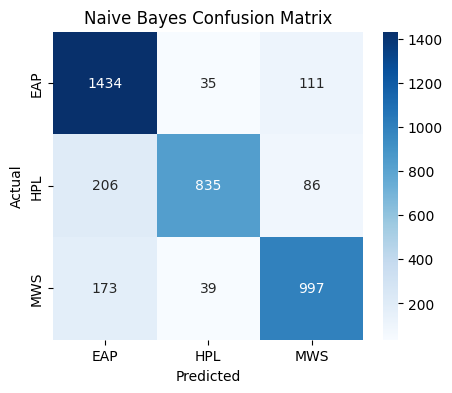

In [ ]:
# ===============================
# Multinomial Naive Bayes Model
# ===============================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes F1-score:", nb_f1)
nb_accuracy = accuracy_score(y_test, y_pred_nb)


# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb),
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Logistic Regression**

Logistic Regression Accuracy: 0.8291624106230848
Logistic Regression F1-score: 0.8288263149937964


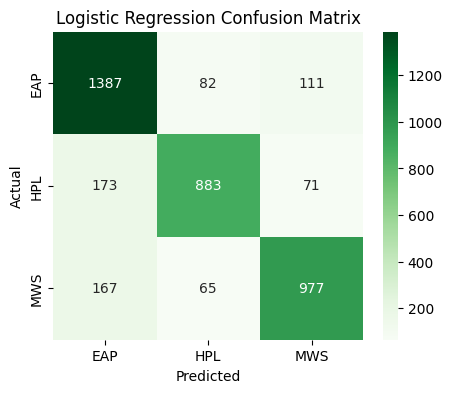

In [ ]:
# ===============================
# Logistic Regression Model
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
lr_model = LogisticRegression(C=3, max_iter=3000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression F1-score:", lr_f1)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d',
            cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Linear SVM

Linear SVM Accuracy: 0.8306945863125639
Linear SVM F1-score: 0.8305226713359054


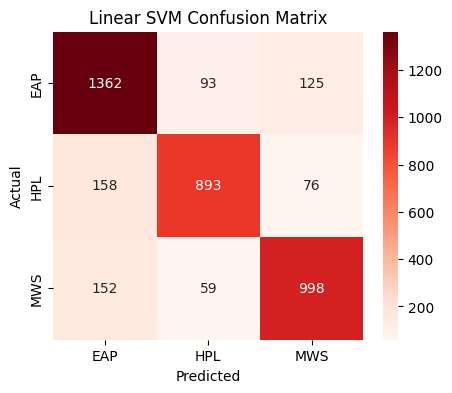

In [ ]:
# ===============================
# Linear SVM Model
# ===============================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM F1-score:", svm_f1)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d',
            cmap='Reds',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Accuracy": [nb_accuracy, lr_accuracy, svm_accuracy],
    "F1-score": [nb_f1, lr_f1, svm_f1]
})

display(results_df)

,Model,Accuracy,F1-score
0,Naive Bayes,0.834014,0.833288
1,Logistic Regression,0.829162,0.828826
2,Linear SVM,0.830695,0.830523


#validation of the model

In [ ]:
# ============================================
# Function: Predict author for new sentences
# ============================================

def predict_author(sentences, model):


    # Preprocess
    cleaned_sentences = [preprocess_pipeline(text) for text in sentences]

    # Vectorize
    X_new = tfidf.transform(cleaned_sentences)

    # Predict numeric labels
    y_pred = nb_model.predict(X_new)

    # Get predicted author names
    authors = le.inverse_transform(y_pred)

    # If model supports probabilities → show confidence
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_new)
        confidences = probs.max(axis=1)
    else:
        confidences = ["N/A"] * len(authors)

    # Print results
    print("\n================ PREDICTIONS ================\n")
    for sent, author, conf in zip(sentences, authors, confidences):
        print(f"Sentence: {sent}")
        print(f"Predicted Author: {author}")
        print(f"Confidence: {conf:.3f}" if conf != "N/A" else "Confidence: N/A")
        print("--------------------------------------------")

In [ ]:
test_sentences = [
    # HPL style (cosmic horror / supernatural)
    "The cyclopean towers loomed over the misty valley, defying reason and human comprehension.",
    "Ancient whispers echoed through the cavern, carrying madness from beyond the stars.",

    # MWS style (emotional / reflective)
    "She wandered through the garden, her heart weighed down by sorrow and longing.",
    "Tears glistened in his eyes as he embraced the fleeting warmth of hope.",

    # EAP style (psychological / Gothic suspense)
    "Shadows writhed along the walls as if alive with a will of their own.",
    "In the dim light of the chamber, a sense of impending doom pressed heavily upon him.",

    # Mixed Gothic (dramatic / atmospheric, borderline)
    "Lightning split the sky, revealing the silhouette of the abandoned manor.",
    "A chilling fog crept over the moors, muffling the distant cries of the night."
]
predict_author(test_sentences, nb_model)   # or lr_model or svm_model



================ PREDICTIONS ================

Sentence: The cyclopean towers loomed over the misty valley, defying reason and human comprehension.
Predicted Author: HPL
Confidence: 0.576
--------------------------------------------
Sentence: Ancient whispers echoed through the cavern, carrying madness from beyond the stars.
Predicted Author: HPL
Confidence: 0.714
--------------------------------------------
Sentence: She wandered through the garden, her heart weighed down by sorrow and longing.
Predicted Author: MWS
Confidence: 0.794
--------------------------------------------
Sentence: Tears glistened in his eyes as he embraced the fleeting warmth of hope.
Predicted Author: MWS
Confidence: 0.678
--------------------------------------------
Sentence: Shadows writhed along the walls as if alive with a will of their own.
Predicted Author: EAP
Confidence: 0.415
--------------------------------------------
Sentence: In the dim light of the chamber, a sense of impending doom pressed heav

#saving The Model

In [ ]:
import joblib

joblib.dump(nb_model, 'my_model.pkl')

loaded_model = joblib.load('my_model.pkl')

In [ ]:
def predict_author_nb(text):

    # Preprocess
    cleaned_text = preprocess_pipeline(text)

    # Vectorize
    X_new = tfidf.transform([cleaned_text])

    # Predict
    y_pred = nb_model.predict(X_new)

    # Decode label
    author = le.inverse_transform(y_pred)[0]

    # Confidence
    probs = nb_model.predict_proba(X_new)
    confidence = probs.max()

    return author, confidence, nb_accuracy


In [ ]:
from IPython.display import display
from IPython.display import HTML
import ipywidgets as widgets

text_box = widgets.Textarea(
    placeholder="Enter text here",
    layout=widgets.Layout(width="700px", height="150px")
)

button = widgets.Button(description="Predict Author")
output = widgets.Output()

def on_click(b):
    with output:
        output.clear_output()
        author, confidence, accuracy = predict_author_nb(text_box.value)

        display(HTML(f"<b>Predicted Author:</b> {author}"))
        display(HTML(f"<b>Confidence:</b> {round(confidence, 3)}"))
        display(HTML(
            f"<b style='color:blue;'>Model Accuracy:</b> "
            f"<span style='color:blue;'>{round(accuracy, 3)}</span>"
        ))

button.on_click(on_click)

display(text_box, button, output)


Textarea(value='', layout=Layout(height='150px', width='700px'), placeholder='Enter text here')

Button(description='Predict Author', style=ButtonStyle())

Output()